In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

# Define source and destination paths
drive_path = "/content/drive/My Drive/landscape-image-colorization.zip"
local_path = "/content/"

!unzip -q "{drive_path}" -d "{local_path}"


data_path = '/content/landscape-image-colorization/'

# Now load your data using your preferred library (e.g., PyTorch DataLoader, TensorFlow, Pandas)


# import kagglehub
# theblackmamba31_landscape_image_colorization_path = kagglehub.dataset_download('theblackmamba31/landscape-image-colorization')

# print('Data source import complete.')
#

Mounted at /content/drive


In [ ]:
ab_model_path = 'drive/MyDrive/my_model_abcolorizationEpoch9.h5'
hs_model_path = 'drive/MyDrive/my_model_hscolorizationEpoch9.h5'

In [ ]:
# import random

# import shutil
# import os

# filenames= []
# for filename in os.listdir(os.path.join('landscape Images/' , 'gray')):
#   filenames.append(filename)

# # print (filenames)
# random_selection = random.sample(filenames, k=int(len(filenames)*0.8))


# # Define the source file path and the destination directory path
# gray_src = os.path.join('landscape Images/' , 'gray')
# color_src = os.path.join('landscape Images/' , 'color')  # Replace with the actual path to your file

# X_train_dest = os.path.join('landscape Images/' , 'train/X')
# Y_train_dest = os.path.join('landscape Images/' , 'train/Y')
# X_test_dest = os.path.join('landscape Images/' , 'test/X')
# Y_test_dest = os.path.join('landscape Images/' , 'test/Y')

# # Ensure the destination directory exists
# os.makedirs(X_train_dest, exist_ok=True)
# os.makedirs(Y_train_dest, exist_ok=True)
# os.makedirs(X_test_dest, exist_ok=True)
# os.makedirs(Y_test_dest, exist_ok=True)

# for filename in filenames:
#   if filename in random_selection:
#     try:
#         # Copy the file
#         shutil.copy(os.path.join(gray_src,filename), os.path.join(X_train_dest,filename))
#         shutil.copy(os.path.join(color_src,filename), os.path.join(Y_train_dest,filename))
#     except FileNotFoundError:
#         print(f"Error: Source file not found.")
#     except Exception as e:
#         print(f"An error occurred: {e}")
#   else:
#     try:
#         # Copy the file
#         shutil.copy(os.path.join(gray_src,filename), os.path.join(X_test_dest,filename))
#         shutil.copy(os.path.join(color_src,filename), os.path.join(Y_test_dest,filename))
#     except FileNotFoundError:
#         print(f"Error: Source file not found.00 ")
#     except Exception as e:
#         print(f"An error occurred: {e}00")


In [ ]:
!pip install tensorflow
!pip install opencv-python

In [ ]:
import os
import os
import tensorflow as tf
# import config as config
import numpy as np
import cv2
# import dataClass as data
import datetime
from functools import partial

import keras
from keras import applications
from keras.callbacks import TensorBoard
from keras.optimizers import Adam
from keras.layers import Input
from keras.layers import concatenate, Reshape
from keras.layers import LeakyReLU
from keras import backend as K
from keras.models import load_model, model_from_json, Model
from tqdm import tqdm


# from tensorflow.keras.applications.vgg19 import VGG19
# from tensorflow.keras import backend as K

tf.config.run_functions_eagerly(True) # For tf.function contexts


# DIRECTORY INFORMATION
# DATASET = "imagenet" # UPDATE

# ROOT_DIR = os.path.abspath('/content/landscape-image-colorization/')
DATA_DIR = "landscape Images"
OUT_DIR = 'colorme/RESULT'
MODEL_DIR = "drive/MyDrive/Model_Exports"
LOG_DIR = 'colorme/LOGS'

TRAIN_DIR = "drive/MyDrive/X" # UPDATE
TEST_DIR = "test/Y" # UPDATE

# DATA INFORMATION
IMAGE_SIZE = 150
BATCH_SIZE = 10

#
# TRAINING INFORMATION
PRETRAINED = "modelPretuned.h5" # UPDATE
NUM_EPOCHS = 2

GRADIENT_PENALTY_WEIGHT = 10


VGG_model = applications.vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
import numpy as np
import cv2
import os

class DATA():

    def __init__(self, dirname):
        self.dir_path = dirname
        # self.dir_path = os.path.join(DATA_DIR, dirname) # dir of images/color and images/grayscale
        self.filelist = os.listdir(self.dir_path) # filenames from color and grayscale
        self.batch_size = BATCH_SIZE
        self.size = len(self.filelist) # dataset size
        self.data_index = 0

    def read_img(self, filename):
        img = cv2.imread(filename, 3)
        # Resize the original 'img' to IMAGE_SIZE for consistency
        img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

        labimg = cv2.cvtColor(img_resized, cv2.COLOR_BGR2Lab)
        # labimg_ori for sampling should also be resized to IMAGE_SIZE
        labimg_ori_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2Lab)

        hsvimg = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)

        edges = cv2.Canny(img_resized,100,200)
        edges = cv2.resize(edges, (IMAGE_SIZE, IMAGE_SIZE))
        edges = edges[:,:,np.newaxis]  # Add channel dimension

        # labimg[:,:,0] is L
        # labimg[:,:,1:] is ab
        # return  X =  L of (shape of image,1), Y = ab, rbg, L_original
        return np.reshape(labimg[:,:,0], (IMAGE_SIZE, IMAGE_SIZE, 1)), \
               labimg[:, :, 1:], \
               hsvimg[:,:, :2], \
               edges, \
               img_resized, \
               labimg_ori_resized[:,:,0]



    def generate_batch(self):
        # edge_list = []
        batch = []
        labels = []
        filelist = []
        labimg_oritList= []
        originalList = []
        for i in range(self.batch_size):
            filename = os.path.join(self.dir_path, self.filelist[self.data_index])
            filelist.append(self.filelist[self.data_index])
            greyimg, colorimg,hsimg,edges,original,labimg_ori = self.read_img(filename)
            batch.append(greyimg) # L
            labels.append(np.concatenate((colorimg,hsimg), axis=-1))
            # labels.append(np.concatenate((colorimg,hsimg,edges), axis=-1)) # ab + hs + edges -> 5 channels
            # edge_list.append(edges)
            originalList.append(original) # rbg
            labimg_oritList.append(labimg_ori) #
            self.data_index = (self.data_index + 1) % self.size
        batch = np.asarray(batch)/255 # values between 0 and 1 -> normalization
        labels = np.asarray(labels)/255 # values between 0 and 1 -> normalization
        originalList = np.asarray(originalList)
        labimg_oritList = np.asarray(labimg_oritList)/255 # values between 0 and 1
        return batch, labels, filelist, originalList, labimg_oritList


class DynamicResizing(keras.Layer):
    """
    Custom Layer to dynamically resize an input tensor (the skip_input)
    to match the height and width of a separate target tensor (x).
    """
    def __init__(self, target_tensor, **kwargs):
        super(DynamicResizing, self).__init__(**kwargs)
        # Store the target tensor (x) that we want to match the size of
        self.target_tensor = target_tensor

    def call(self, skip_input):
        # 1. Get the dynamic target dimensions from the target_tensor
        # tf.shape() correctly returns a symbolic tensor representing the dynamic size
        target_H = tf.shape(self.target_tensor)[1]
        target_W = tf.shape(self.target_tensor)[2]

        # 2. Use tf.image.resize (a low-level tf_fn) inside the call method.
        # This is valid inside a custom Layer's call method.
        return tf.image.resize(
            skip_input,
            size=[target_H, target_W],
            method=tf.image.ResizeMethod.BILINEAR
        )

    def get_config(self):
        # Needed for saving/loading the model
        config = super(DynamicResizing, self).get_config()
        # NOTE: Cannot serialize the target_tensor itself, must be used in call.
        return config

In [ ]:
import tensorflow as tf
from keras.layers import Input, Conv2D, LeakyReLU, UpSampling2D, Concatenate, Lambda, Layer
from keras.applications.vgg19 import VGG19
from keras import backend as K
import numpy as np
import os, datetime
from tqdm import tqdm
from keras.models import load_model
import keras.layers as keras_layers # Use an alias for clarity
import csv
# --- New Custom Layer for Renaming (Fixes tf.identity ValueError) ---
class NameAssigner(Layer):
    """Simple layer to assign a specific name to a tensor using tf.identity."""
    def __init__(self, output_name, **kwargs):
        super(NameAssigner, self).__init__(**kwargs)
        self.output_name = output_name

    def call(self, x):
        # tf.identity is safe within the call() method of a custom layer
        return tf.identity(x, name=self.output_name)

# --- Custom Layer for Dynamic Resizing (Fixes U-Net Shape Mismatch) ---
class DynamicResizing(Layer):
    def __init__(self, target_tensor, **kwargs):
        super(DynamicResizing, self).__init__(**kwargs)
        self.target_tensor = target_tensor

    def call(self, skip_input):
        target_H = tf.shape(self.target_tensor)[1]
        target_W = tf.shape(self.target_tensor)[2]
        return tf.image.resize(
            skip_input,
            size=[target_H, target_W],
            method=tf.image.ResizeMethod.BILINEAR
        )

# --- U-Net UpSampling Block ---
def upsample_block(x, skip_input, filters, kernel_size=3):
    x = UpSampling2D(size=(2, 2))(x)

    if x.shape[1] != skip_input.shape[1] or x.shape[2] != skip_input.shape[2]:
        resizer = DynamicResizing(target_tensor=x)
        skip_input = resizer(skip_input)

    x = Concatenate()([x, skip_input])
    x = keras_layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = keras_layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    return x

# --- VGG Extractor Configuration and Setup ---
FEATURE_LAYER = 'block5_conv4'
IMG_SIZE = 150

def create_vgg_extractor(input_tensor=None):
    """
    Creates a Keras model with robust layer-by-layer connection
    (Fixes Functional.call() error).
    """
    vgg = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    vgg.trainable = False

    if input_tensor is None:
        input_tensor = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    scaled_input = Lambda(lambda x: x * 255.0)(input_tensor)
    preprocessed_input = Lambda(
        tf.keras.applications.vgg19.preprocess_input,
        name='vgg_preprocessing'
    )(scaled_input)

    # --- ROBUST CONNECTION FIX ---
    x = preprocessed_input
    output_tensor = None
    for layer in vgg.layers[1:]:
        layer.trainable = False
        x = layer(x)
        if layer.name == FEATURE_LAYER:
            output_tensor = x
            break

    if output_tensor is None:
        raise ValueError(f"VGG layer '{FEATURE_LAYER}' not found for feature extraction.")

    extractor = Model(inputs=input_tensor, outputs=output_tensor, name='VGG_Feature_Extractor')
    return extractor

# Instantiate the extractor model ONCE globally
VGG_extractor_model = create_vgg_extractor()

# --- Loss Functions (Simplified for Two-Output Model) ---

def vgg_feature_loss(y_true, y_pred):
    return tf.keras.losses.MeanSquaredError()(y_true, y_pred)
pixel_mse_loss = tf.keras.losses.MeanSquaredError()

# --- Dummy functions from original code ---
def write_log(log_dir, names, logs, batch_no):
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        for name, value in zip(names, logs):
            if isinstance(value, np.ndarray) and value.size == 1:
                value = value.item()
            tf.summary.scalar(name, value, step=batch_no)
        writer.flush()

def mse (y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred - y_true))

def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_pred)

def gradient_penalty_loss(y_true, y_pred, averaged_samples, gradient_penalty_weight):
    gradients = K.gradients(y_pred, averaged_samples)[0]
    gradients_sqr = K.square(gradients)
    gradients_sqr_sum = K.sum(gradients_sqr, axis=np.arange(1, len(gradients_sqr.shape)))
    gradient_l2_norm = K.sqrt(gradients_sqr_sum)
    gradient_penalty = gradient_penalty_weight * K.square(1 - gradient_l2_norm)
    return K.mean(gradient_penalty)


def colorization_model(VGG_model,img_shape_3):
    input_img = Input(shape=img_shape_3)
    model_ = Model(VGG_model.input,VGG_model.layers[-6].output)
    model = model_(input_img)

    global_features = keras_layers.Conv2D(512, (3, 3), padding='same', strides=(2, 2), activation='relu')(model)
    global_features = keras_layers.BatchNormalization()(global_features)
    global_features = keras_layers.Conv2D(512, (3, 3), padding='same', strides=(1, 1), activation='relu')(global_features)
    global_features = keras_layers.BatchNormalization()(global_features)

    global_features = keras_layers.Conv2D(512, (3, 3), padding='same', strides=(2, 2), activation='relu')(global_features)
    global_features = keras_layers.BatchNormalization()(global_features)
    global_features = keras_layers.Conv2D(512, (3, 3), padding='same', strides=(1, 1), activation='relu')(global_features)
    global_features = keras_layers.BatchNormalization()(global_features)

    global_features2 = keras_layers.Flatten()(global_features)
    global_features2 = keras_layers.Dense(1024)(global_features2)
    global_features2 = keras_layers.Dense(512)(global_features2)
    global_features2 = keras_layers.Dense(256)(global_features2)
    global_features2 = keras_layers.RepeatVector(18*18)(global_features2)
    global_features2 = keras_layers.Reshape((18,18, 256))(global_features2)

    global_featuresClass = keras_layers.Flatten()(global_features)
    global_featuresClass = keras_layers.Dense(4096)(global_featuresClass)
    global_featuresClass = keras_layers.Dense(4096)(global_featuresClass)
    global_featuresClass = keras_layers.Dense(1000, activation='softmax')(global_featuresClass)

    midlevel_features = keras_layers.Conv2D(512, (3, 3), padding='same', strides=(1, 1), activation='relu')(model)
    midlevel_features = keras_layers.BatchNormalization()(midlevel_features)
    midlevel_features = keras_layers.Conv2D(256, (3, 3), padding='same', strides=(1, 1), activation='relu')(midlevel_features)
    midlevel_features = keras_layers.BatchNormalization()(midlevel_features)

    modelFusion = keras_layers.concatenate([midlevel_features, global_features2])

    outputModel = keras_layers.Conv2D(256, (1, 1), padding='same', strides=(1, 1), activation='relu')(modelFusion)
    outputModel = keras_layers.Conv2D(128, (3, 3), padding='same', strides=(1, 1), activation='relu')(outputModel)

    outputModel = keras_layers.UpSampling2D(size=(2,2))(outputModel)
    outputModel = keras_layers.Conv2D(64, (3, 3), padding='same', strides=(1, 1), activation='relu')(outputModel)
    outputModel = keras_layers.Conv2D(64, (3, 3), padding='same', strides=(1, 1), activation='relu')(outputModel)

    outputModel = keras_layers.UpSampling2D(size=(2,2))(outputModel)
    outputModel = keras_layers.Conv2D(32, (3, 3), padding='same', strides=(1, 1), activation='relu')(outputModel)
    outputModel = keras_layers.Conv2D(2, (3, 3), padding='same', strides=(1, 1), activation='sigmoid')(outputModel)
    outputModel = keras_layers.UpSampling2D(size=(2,2))(outputModel)

    outputModel = tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)(outputModel)

    final_model = Model(inputs=input_img, outputs = [outputModel, global_featuresClass])
    final_model.summary()
    return final_model


def fusion (img_shape_1,img_shape_4):

    def downsample_block(x, filters, kernel_size=3):
        x = keras_layers.Conv2D(filters, kernel_size, padding='same')(x)
        x = keras_layers.BatchNormalization()(x)
        x = LeakyReLU(alpha=0.2)(x)
        x = keras_layers.Conv2D(filters, kernel_size, strides=(2, 2), padding='same')(x)
        x = keras_layers.BatchNormalization()(x)
        x = LeakyReLU(alpha=0.2)(x)
        return x


    input_abhs = Input (shape = img_shape_4, name = 'hs_input')
    # input_abhse = Input (shape = (IMAGE_SIZE, IMAGE_SIZE, 5), name = 'abhse_input')
    input_l = Input(shape= img_shape_1, name='l_input')

    pred_hs = Concatenate() ([input_abhs[:,:,:,2:],input_l])
    pred_ab=input_abhs[:,:,:,:2]
    net = Concatenate()([pred_hs,pred_ab])

    # pred_hs = Concatenate() ([input_abhse[:,:,:,2:4],input_l])
    # pred_ab=input_abhse[:,:,:,:2]
    # edge = input_abhse[:,:,:,4:]
    # net = Concatenate()([pred_hs,pred_ab,edge])

    net = keras_layers.Resizing(152, 152)(net)

    enc1 = downsample_block(net, 64)
    enc2 = downsample_block(enc1, 128)
    enc3 = downsample_block(enc2, 256)

    bottleneck = keras_layers.Conv2D(512, (3, 3), padding='same')(enc3)
    bottleneck = LeakyReLU(alpha=0.2)(bottleneck)

    dec3 = upsample_block(bottleneck, enc2, 256)
    dec2 = upsample_block(dec3, enc1, 128)
    dec1 = upsample_block(dec2, net, 64)


        # 1. Name the final Resizing layer
    final_output = keras_layers.Conv2D(3, (1, 1), activation='tanh', padding='same', name='rgb_conv_output')(dec1)

    # ADD an explicit name to the Resizing layer
    final_output = tf.keras.layers.Resizing(
        IMAGE_SIZE,
        IMAGE_SIZE,
        name='FINAL_RGB_RESIZE' # <-- Give it a FIXED name
    )(final_output)

    # 2. VGG Feature Output Head
    vgg_features_output = VGG_extractor_model(final_output)

    # 3. Rename the NameAssigner layer itself
    vgg_features_output = NameAssigner(
        output_name='vgg_feature_output_tensor',
        name='FINAL_VGG_NAME_ASSIGNER' # <-- Give the LAYER a FIXED name
    )(vgg_features_output)

    # Finalize the model with two outputs
    # final_model = Model(inputs=[input_l, input_abhs],
    #                     outputs=[final_output, vgg_features_output],
    #                     name='Fusion_UNet')
    final_model = Model(inputs=[input_l, input_abhse],
                        outputs=[final_output, vgg_features_output],
                        name='Fusion_UNet')
    final_model.summary()
    return final_model

# --- Training Loop ---
TEST_NAME ="eightTest"
# Assume DATA, LOG_DIR, TRAIN_DIR, TEST_DIR, BATCH_SIZE, NUM_EPOCHS are defined
log_path= os.path.join(LOG_DIR,TEST_NAME)
if not os.path.exists(log_path):
    os.makedirs(log_path)

with open(os.path.join(log_path, str(datetime.datetime.now().strftime("%Y%m%d")) + "_" + str(BATCH_SIZE) + "_" + str(NUM_EPOCHS) + ".txt"), "w") as log:
    log.write(str(datetime.datetime.now()) + "\n")

    print('load training data from '+ TRAIN_DIR)
    train_data = DATA(TRAIN_DIR)
    # test_data = DATA(TEST_DIR)
    assert BATCH_SIZE<=train_data.size, "The batch size should be smaller or equal to the number of training images --> modify it in py"
    print("Train data loaded")

    print("Initiliazing Model...")
    save_models_path =os.path.join(MODEL_DIR,TEST_NAME)
    if not os.path.exists(save_models_path):
        os.makedirs(save_models_path)

    ABcolorizationModel = load_model(ab_model_path, compile=False)
    HScolorizationModel = load_model(hs_model_path, compile=False)

    fusion_model = fusion((IMAGE_SIZE,IMAGE_SIZE,1),(IMAGE_SIZE,IMAGE_SIZE,5))
    # fusion_model.load_weights('drive/MyDrive/Model_Exports/eightTest/my_model_fusionEpoch90.keras')

    def safe_psnr(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        return tf.image.psnr(y_true, y_pred, max_val=2.0) # <--- Changed to 2.0

    def safe_ssim(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        return tf.image.ssim(y_true, y_pred, max_val=2.0, filter_size=11, k1=0.01, k2=0.03) # <--- Changed to 2.0
    # --- FINAL CORRECTED COMPILATION ---
    RGB_OUTPUT_NAME = 'FINAL_RGB_RESIZE'  # Name of the Resizing layer for RGB output
    VGG_OUTPUT_NAME = 'FINAL_VGG_NAME_ASSIGNER'  # Name assigned by
    fusion_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            RGB_OUTPUT_NAME: pixel_mse_loss,                 # Key matches the Resizing layer name
            VGG_OUTPUT_NAME: vgg_feature_loss       # Key matches the NameAssigner layer name
        },
        loss_weights=[1.0, 0.05],
        metrics={
        RGB_OUTPUT_NAME: ['mse', safe_psnr, safe_ssim], # Use the safe wrappers
        VGG_OUTPUT_NAME: ['mse']
        }
    )

    print("Model Initialized!")
    print ("Model_Metric: ", fusion_model.metrics_names)

    total_batch = int(train_data.size/BATCH_SIZE)
    prev = 1000
    for epoch in range(30):
        with tqdm(total=total_batch,unit= 'batch') as tepoch:
            tepoch.set_description(f'Epoch {epoch+1}')
            train_loss = 0
            val_loss = 0

            tf.keras.utils.disable_interactive_logging()
            for batch in range(total_batch):
                tepoch.update(1)

                trainL, trainABHS, _, original, l_img_oritList = train_data.generate_batch()
                l_3=np.tile(trainL,[1,1,1,3])


                scaled_original = (original / 127.5) - 1.0 # Scales from [0, 255] to [-1, 1]
                # Use the same scaled target we created above for the RGB loss:
                original_tensor = tf.convert_to_tensor(scaled_original, dtype=tf.float32)


                original_vgg_features = VGG_extractor_model(original_tensor, training=False)
                original_vgg_features = original_vgg_features.numpy()

                predAB,_ = ABcolorizationModel.predict(l_3)
                predHS,_ = HScolorizationModel.predict(l_3)
                edge =  trainABHS[:,:,:,4:]
                predABHS = np.concatenate((predAB, predHS), axis=-1)
                # predABHS = np.concatenate((predAB, predHS, edge), axis=-1)

                # --- CORRECTED TRAINING CALL ---
                f_loss = fusion_model.train_on_batch(
                    [trainL, predABHS],
                    [scaled_original, original_vgg_features] # Target 1 (RGB) and Target 2 (GT Features)
                )


                train_loss += f_loss[0]

            tf.keras.utils.enable_interactive_logging()
            with open('drive/MyDrive/new_data_log.csv', 'a', newline='') as file:
                              writer = csv.writer(file)
                              writer.writerow(f_loss)
                            # fusion_model.fit(x=[trainL, predABHS],
                            #                  y=[scaled_original, original_vgg_features],
                            #                  verbose=0,batch_size=BATCH_SIZE,epochs=1)



            # print ("\n",train_loss,train_loss/total_batch,prev,prev-(train_loss/total_batch))
            tepoch.set_postfix({'Train loss': train_loss})
            if epoch % 10 == 0:
                save_path = os.path.join(save_models_path, "my_model_fusionEpoch%d.keras" % (epoch+100))
                fusion_model.save(save_path)
            prev = train_loss/total_batch
save_path = os.path.join(save_models_path, "my_model_fusionEpoch%d.keras" % (epoch+100))
fusion_model.save(save_path)

load training data from drive/MyDrive/X
Train data loaded
Initiliazing Model...


RuntimeError: Can't decrement id ref count (unable to close file, errno = 107, error message = 'Transport endpoint is not connected')

In [ ]:

def deprocess(imgs):
    imgs = imgs * 255
    imgs[imgs > 255] = 255
    imgs[imgs < 0] = 0
    return imgs.astype(np.uint8)


def reconstruct(batchX, predictedY, filelist): # fusion of ab+L
    ab = predictedY [:,:,:2]
    hs = predictedY [:,:,2:]
    ab_result = np.concatenate((batchX, ab), axis=2)
    ab_result = cv2.cvtColor(ab_result, cv2.COLOR_Lab2BGR)

    hs_result = np.concatenate(( hs,batchX), axis=2)
    hs_result = cv2.cvtColor(hs_result, cv2.COLOR_HSV2BGR)


    save_results_path = os.path.join(OUT_DIR,TEST_NAME)
    if not os.path.exists(save_results_path):
        os.makedirs(save_results_path)
    save_path = os.path.join(save_results_path, filelist +  "_ab.jpg" )
    cv2.imwrite(save_path, ab_result)
    save_path = os.path.join(save_results_path, filelist +  "_hsv.jpg" )
    cv2.imwrite(save_path, hs_result)
    return ab_result,hs_result

def reconstruct_no(batchX, predictedY):
    ab = predictedY [:,:,:2]
    hs = predictedY [:,:,2:]
    ab_result = np.concatenate((batchX, ab), axis=2)
    ab_result = cv2.cvtColor(ab_result, cv2.COLOR_Lab2BGR)

    hs_result = np.concatenate(( hs,batchX), axis=2)
    hs_result = cv2.cvtColor(hs_result, cv2.COLOR_HSV2BGR)
    return ab_result, hs_result

def correct_deprocess(imgs):
    # 1. Map from [-1, 1] to [0, 2]
    imgs = imgs + 1
    # 2. Map from [0, 2] to [0, 255]
    imgs = imgs * 127.5

    # Clipping and Type conversion (The clipping here is now mostly a safety net)
    imgs[imgs > 255] = 255
    imgs[imgs < 0] = 0
    return imgs.astype(np.uint8)

def evaluation_metrics(original, predrbg,predABHS, testL):


    original_rgb_float = original.astype(np.float32)
    pred_rgb_combined_scaled = correct_deprocess(predrbg).astype(np.float32)

    psnr_combined = tf.image.psnr(pred_rgb_combined_scaled, original_rgb_float, max_val=255.0)
    ssim_combined = tf.image.ssim(pred_rgb_combined_scaled, original_rgb_float, max_val=255.0)
    print(f"Fusion PSNR: {tf.reduce_mean(psnr_combined).numpy():.4f}")
    print(f"Fusion Model SSIM: {tf.reduce_mean(ssim_combined).numpy():.4f}")


    reconstructed_rgb_colorization_batch = []
    reconstructed_hsv_colorization_batch = [] # New list for HSV reconstructed images
    for i in range(BATCH_SIZE):
        l_channel_deprocessed = deprocess(testL[i, :, :, 0])
        l_channel_deprocessed_expanded = np.expand_dims(l_channel_deprocessed, axis=-1)
        predicted_ab_hs_deprocessed = deprocess(predABHS[i])

        # Reconstruct from Lab
        ab_recon, hs_recon = reconstruct_no(l_channel_deprocessed_expanded, predicted_ab_hs_deprocessed)
        reconstructed_rgb_colorization_batch.append(ab_recon)
        reconstructed_hsv_colorization_batch.append(hs_recon) # Store HSV reconstructed image

    reconstructed_rgb_colorization_batch = np.array(reconstructed_rgb_colorization_batch).astype(np.float32)
    reconstructed_hsv_colorization_batch = np.array(reconstructed_hsv_colorization_batch).astype(np.float32) # Convert to numpy array


    psnr_colorization = tf.image.psnr(reconstructed_rgb_colorization_batch, original_rgb_float, max_val=255.0)
    ssim_colorization = tf.image.ssim(reconstructed_rgb_colorization_batch, original_rgb_float, max_val=255.0)
    print(f"AB Reconstructed PSNR (Lab-based): {tf.reduce_mean(psnr_colorization).numpy():.4f}")
    print(f"AB Reconstructed SSIM (Lab-based): {tf.reduce_mean(ssim_colorization).numpy():.4f}")

    # PSNR and SSIM for HSV-based reconstruction
    psnr_hsv_colorization = tf.image.psnr(reconstructed_hsv_colorization_batch, original_rgb_float, max_val=255.0)
    ssim_hsv_colorization = tf.image.ssim(reconstructed_hsv_colorization_batch, original_rgb_float, max_val=255.0)
    print(f"HSV Reconstructed PSNR (HSV-based): {tf.reduce_mean(psnr_hsv_colorization).numpy():.4f}")
    print(f"HSV Reconstructed SSIM (HSV-based): {tf.reduce_mean(ssim_hsv_colorization).numpy():.4f}")
    return



In [ ]:


# testL, _ ,  filelist, original, labimg_oritList  = test_data.generate_batch()

# # predict AB channels
# predAB, _  = ABcolorizationModel.predict(np.tile(testL,[1,1,1,3]))
# predHS,_ = HScolorizationModel.predict(np.tile(testL,[1,1,1,3]))
# edge =  test_data.generate_batch()[1][:,:,:,4:]
# predABHS = np.concatenate((predAB, predHS, edge), axis=-1)
# predrbg = fusion_model.predict([testL, predABHS])
# evaluation_metrics(original, predrbg,predABHS, testL)

# new_fusion_model = fusion((IMAGE_SIZE,IMAGE_SIZE,1),(IMAGE_SIZE,IMAGE_SIZE,4))
# new_fusion_model.load_weights('colorme\\Model_Exports\\ForthTest\\my_model_fusionEpoch30.h5')
# new_fusion_model.compile(optimizer=optimizerF, loss='mse')

# predrbg_new = new_fusion_model.predict([testL, predABHS])

# evaluation_metrics(original, predrbg_new,predABHS, testL)

c:\Users\sarah\Documents\Projects\nn\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Fusion PSNR: 4.2833
Fusion Model SSIM: 0.2045
AB Reconstructed PSNR (Lab-based): 26.8075
AB Reconstructed SSIM (Lab-based): 0.9630
HSV Reconstructed PSNR (HSV-based): 7.9552
HSV Reconstructed SSIM (HSV-based): 0.1337


Fusion PSNR: 4.2868
Fusion Model SSIM: 0.2048
AB Reconstructed PSNR (Lab-based): 26.8075
AB Reconstructed SSIM (Lab-based): 0.9630
HSV Reconstructed PSNR (HSV-based): 7.9552
HSV Reconstructed SSIM (HSV-based): 0.1337


In [ ]:
test_batch = int(train_data.size/BATCH_SIZE)
for _ in range(test_batch):
  testL, _ ,  filelist, original, labimg_oritList  = test_data.generate_batch()
  # predict AB channels
  predAB, _  = ABcolorizationModel.predict(np.tile(testL,[1,1,1,3]))
  predHS,_ = HScolorizationModel.predict(np.tile(testL,[1,1,1,3]))
  # edge =  test_data.generate_batch()[1][:,:,:,4:]
  # predABHS = np.concatenate((predAB, predHS, edge), axis=-1)
  predABHS = np.concatenate((predAB, predHS), axis=-1)
  predrbg,_ = fusion_model.predict([testL, predABHS])
  evaluation_metrics(original, predrbg,predABHS, testL)

Fusion PSNR: 21.8300
Fusion Model SSIM: 0.8034
AB Reconstructed PSNR (Lab-based): 25.9639
AB Reconstructed SSIM (Lab-based): 0.9090
HSV Reconstructed PSNR (HSV-based): 24.4331
HSV Reconstructed SSIM (HSV-based): 0.9546


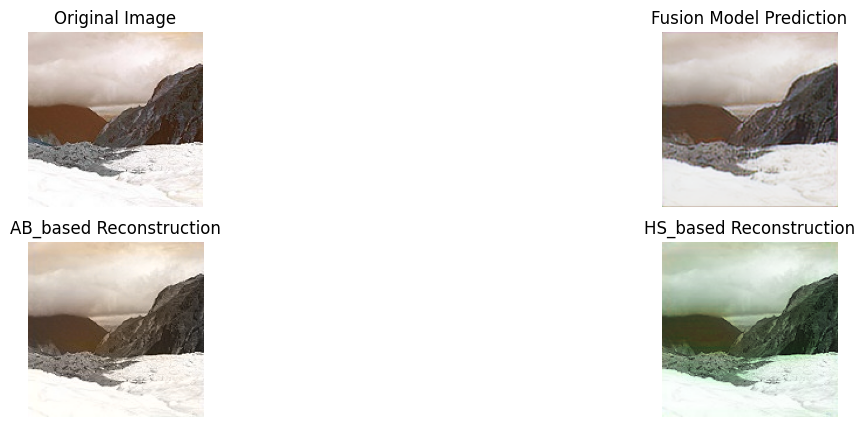

In [ ]:
import matplotlib.pyplot as plt


testL, _ ,  filelist, original, labimg_oritList  = test_data.generate_batch()

# predict AB channels
predAB, _  = ABcolorizationModel.predict(np.tile(testL,[1,1,1,3]))
predHS,_ = HScolorizationModel.predict(np.tile(testL,[1,1,1,3]))
# edge =  test_data.generate_batch()[1][:,:,:,4:]
# predABHS = np.concatenate((predAB, predHS, edge), axis=-1)
predABHS = np.concatenate((predAB, predHS), axis=-1)
predrbg,_ = fusion_model.predict([testL, predABHS])
evaluation_metrics(original, predrbg,predABHS, testL)

i = 0
l_channel_deprocessed = deprocess(testL[i, :, :, 0])
l_channel_deprocessed_expanded = np.expand_dims(l_channel_deprocessed, axis=-1)
predicted_ab_hs_deprocessed = deprocess(predABHS[i])

reconstruct(l_channel_deprocessed_expanded, predicted_ab_hs_deprocessed,filelist=filelist[i])
ab_recon, hs_recon = reconstruct_no(l_channel_deprocessed_expanded, predicted_ab_hs_deprocessed)


save_results_path = os.path.join(OUT_DIR,TEST_NAME)
if not os.path.exists(save_results_path):
    os.makedirs(save_results_path)
save_path = os.path.join(save_results_path, filelist[i] +  "_fusion.jpg" )
cv2.imwrite(save_path, correct_deprocess(predrbg[0]))

plt.subplots(2,2, figsize=(15,5))
plt.subplot(2,2,1)
plt.imshow(original[0])
plt.title('Original Image')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(correct_deprocess(predrbg[0]))
plt.title('Fusion Model Prediction')
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(ab_recon)
plt.title('AB_based Reconstruction')
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(hs_recon)
plt.title('HS_based Reconstruction')
plt.axis('off')
plt.show()
